# An implementation of Multi-Task Learning using convolutional neural networks.

## Introduction:
Multi-Task Learning is a machine learning technique where you try to use one large model to predict 2 different outputs where the feature space is very similar.  This allows the model to "Share Information" within one another so that instead of having 2 independent predictions.  You create 2 predcitions that learn from eachother.

In this case study, we want to predict 2 different values: a categorical value **classifying* the time frame that a customer will purchase a ticket, as well as an explicitely prediction of how many days in advance the customer will purchase a ticket. 

# Build Network Architecture

## Imports

In [105]:
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader 
import dotenv as de

import numpy as np
import pandas as pd 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, r2_score, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Class 1: Dataset Prep
A key step in dataset prep is to properly convert all of the columns into torch tensors for preparation for the archetecture. The constructor acomplishes the following tasks
- Rescale numeric columns using standard scaler
- Encode categorical columns using LabelEncoder()
- convert label vectors to torch tensors. 

In [106]:
class TicketDataset(Dataset):
    def __init__(
        self, df, numeric_cols, categorical_cols,
        reg_target, clf_target, scalar=None,
        encoders=None, clf_encoder=None, fit=True
    ):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols

        num_data = df[numeric_cols].to_numpy(dtype=np.float32)

        if fit:
            self.scalar = StandardScaler()
            num_data = self.scalar.fit_transform(num_data)
        else:
            self.scalar = scalar
            num_data = self.scalar.transform(num_data)

        self.num_data = torch.tensor(num_data, dtype=torch.float32)

        self.encoders = encoders if encoders is not None else {}
        cat_encoded = []

        for col in categorical_cols:
            if fit:
                encoder = LabelEncoder()
                encoded = encoder.fit_transform(df[col].astype(str))
                self.encoders[col] = encoder
            else:
                encoder = self.encoders[col]
                encoded = df[col].astype(str).map(
                    lambda value: (
                        encoder.transform([value])[0]
                        if value in encoder.classes_ else 0
                    )
                ).to_numpy()

            cat_encoded.append(encoded)

        # --- FIX: guard the empty case ---
        if categorical_cols:
            self.cat_data = torch.tensor(
                np.stack(cat_encoded, axis=1), dtype=torch.long
            )
        else:
            self.cat_data = torch.empty((len(df), 0), dtype=torch.long)

        if fit:
            self.clf_encoder = LabelEncoder()
            clf_encoded = self.clf_encoder.fit_transform(
                df[clf_target].astype(str)
            )
        else:
            self.clf_encoder = clf_encoder
            clf_encoded = self.clf_encoder.transform(
                df[clf_target].astype(str)
            )

        self.reg_y = torch.tensor(
            df[reg_target].to_numpy(dtype=np.float32)
        )
        self.clf_y = torch.tensor(clf_encoded, dtype=torch.long)

    def __len__(self):
        return len(self.reg_y)

    def __getitem__(self, index):
        return (
            self.num_data[index],
            self.cat_data[index],
            self.reg_y[index],
            self.clf_y[index],
        )

## Class 2 & 3: Multi-Task Network & Uncertainty Weight
The key hurdle that Multi-Task Learning faces compared to traditional modeling approaches is that we require a unified loss function that encompases both regression and classfication.  I.e. our "loss function" will be a weighted average between the 2 
$$
    Loss = \omega_1 * (Regression Loss) + \omega_2 * (Classification Loss)
$$
Each sub problem will have loss function
- Regression Loss -> Smooth L1 - Loss
- Classification Loss -> Categorical Cross Entropy

During training these weights will dynamically update.

In [107]:
class MultiTaskNet(nn.Module):
    def __init__(
            self,
            num_numeric,
            cat_cardinalities,
            n_classes=3,
            trunk_dims=(64,32),
            emb_dropout=0.1,
            trunk_dropout=0.2
    ):

        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(card, min(50, (card + 1) // 2))
            for card in cat_cardinalities 
        ])
        emb_total = sum(min(50, (c + 1) // 2) for c in cat_cardinalities)
        self.emb_dropout = nn.Dropout(emb_dropout)

        input_dim = num_numeric + emb_total 

        trunk_layers = []
        prev = input_dim
        for dim in trunk_dims:
            trunk_layers += [
                nn.Linear(prev, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(trunk_dropout)
            ]
            prev=dim 

        self.trunk = nn.Sequential(*trunk_layers)
        trunk_out = prev

        # --- Task Heads --- 
        self.reg_head = nn.Sequential(
            nn.Linear(trunk_out, trunk_out // 2), nn.ReLU(),
            nn.Linear(trunk_out // 2, 1) 
        )
        self.clf_head = nn.Sequential(
            nn.Linear(trunk_out, trunk_out // 2), nn.ReLU(),
            nn.Linear(trunk_out // 2, n_classes)
        )

    def forward(self, x_num, x_cat):
        if len(self.embeddings) > 0:
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x_cat_emb = self.emb_dropout(torch.cat(embs, dim=1))
            x = torch.cat([x_num, x_cat_emb], dim = 1)
        else:
            x = x_num 

        shared = self.trunk(x)
        reg_out = self.reg_head(shared).squeeze(-1)
        clf_logits = self.clf_head(shared)
        return reg_out, clf_logits


class UncertaintyWeightedLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.log_var_reg = nn.Parameter(torch.zeros(1))
        self.log_var_clf = nn.Parameter(torch.zeros(1))

    def forward(self, reg_pred, reg_true, clf_logits, clf_true):
        reg_loss = F.smooth_l1_loss(reg_pred, reg_true)
        clf_loss = F.cross_entropy(clf_logits, clf_true)

        loss = (
            torch.exp(-self.log_var_reg) * reg_loss + self.log_var_reg
            + torch.exp(-self.log_var_clf) * clf_loss + self.log_var_clf
        )
        return loss.squeeze(), reg_loss.item(), clf_loss.item()

### Train and Evaluation functions

In [108]:
def train(model, loss_fn, train_loader, val_loader, epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(loss_fn.parameters()), lr=lr
    )

    device = 'cuda' if torch.cuda.is_available() else 'cpu' 
    model.to(device); loss_fn.to(device)

    for epoch in range(epochs):
        model.train()
        for x_num, x_cat, reg_y, clf_y in train_loader:
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            reg_y, clf_y = reg_y.to(device), clf_y.to(device)

            optimizer.zero_grad()
            reg_pred, clf_logits = model(x_num, x_cat)
            loss, r_loss, c_loss = loss_fn(reg_pred, reg_y, clf_logits, clf_y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_mae, val_acc, n = 0, 0, 0
        with torch.no_grad():
            for x_num, x_cat, reg_y, clf_y in val_loader:
                x_num, x_cat = x_num.to(device), x_cat.to(device)
                reg_y, clf_y = reg_y.to(device), clf_y.to(device)
                reg_pred, clf_logits = model(x_num, x_cat)
                val_mae += (reg_pred - reg_y).abs().sum().item()
                val_acc += (clf_logits.argmax(1) == clf_y).sum().item()
                n += len(reg_y)
        print(f"Epoch {epoch+1:3d} | reg_loss {r_loss:.3f} "
            f"clf_loss {c_loss:.3f} | val log-MAE {val_mae/n:.3f} "
            f"val Acc {val_acc/n:.3f}")



@torch.no_grad()
def collect_predictions(model, loader, device, multitask=True):
    model.eval()
    reg_preds, reg_trues, clf_preds, clf_trues = [], [], [], []
    for x_num, x_cat, reg_y, clf_y in loader:
        x_num, x_cat = x_num.to(device), x_cat.to(device)
        reg_out, clf_logits = model(x_num, x_cat)
        reg_preds.append(reg_out.cpu().numpy())
        clf_preds.append(clf_logits.argmax(1).cpu().numpy())
        reg_trues.append(reg_y.numpy())
        clf_trues.append(clf_y.numpy())

    reg_pred = np.concatenate(reg_preds)
    reg_true = np.concatenate(reg_trues)


    return (reg_pred, reg_true,
            np.concatenate(clf_preds), np.concatenate(clf_trues))

def report_metrics(reg_pred, reg_true, clf_pred, clf_true, label=""):
    mae = mean_absolute_error(reg_true, reg_pred)
    r2 = r2_score(reg_true, reg_pred)
    rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))

    acc = accuracy_score(clf_true, clf_pred)
    f1 = f1_score(clf_true, clf_pred, average='macro')

    print(f"===== {label} =====")
    print(f"  Regression   | MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")
    print(f"  Classification   | Acc: {acc:.3f}  Macro-F1: {f1:.3f}")
    return {'mae' : mae, 'rmse' : rmse, 'R2' : r2, 'acc' : acc, 'f1' : f1}

# Network Training

## Build Dataset
This cell loads the excel file from my local directory and provides 

In [109]:
DATASET_NAME = de.get_key(".env", "DATASET_NAME")

data = pd.read_excel(f"data/{DATASET_NAME}", sheet_name = [1,2]) #Load in the 2nd and 3rd sheets of the excel file (all other sheets contain metadata and are not relevant)
DATA_ORIGINAL = pd.concat([data[1], data[2]], axis=0, ignore_index=True)
def preprocess_dataframe(df_orig):
    df = df_orig.copy() #Copy the original dataset

    df['Fan_Mailing_List'] = df['Fan_Mailing_List'].map({"Yes" : 1, "No" : 0}).astype(bool)
    df['Seat_Is_Upper'] = df['Seat_Location'].map({"Upper" : 1, "Lower" : 0}).astype(bool)

    df['Days_Before_Game'] = df['Days_Before_Game'].astype("float64")

    return df 

DATA = preprocess_dataframe(DATA_ORIGINAL)

# ----------------- Change to test different features -----------------------
numeric_cols = ['Num_Tickets_Purchased', 'Age', 'Ticket_Price', 'Seat_Is_Upper', 'Fan_Mailing_List']
categorical_cols = []

# --- Labels --- 
reg_label='Days_Before_Game' #Regression Label
clf_label = 'Customer_Type' #Categorical Label

# ----------------------------------------------------------------------------


X = DATA[numeric_cols + categorical_cols]
y_reg = DATA[reg_label]
y_clf = DATA[clf_label]


## Apply K-Fold cross validation and train each individual split
- Train the Multi-Task Model
- Train 2 individual models
    - regression: RandomForestRegressor()
    - classification: RandomForestClassifier()

In [110]:
# --------- Training Parameters (CHANGE) --------
num_splits = 10
epochs = 50
# -----------------------------------------------

In [111]:
skf = StratifiedKFold(n_splits=num_splits, random_state=42, shuffle=True)

fold_scores = []
confusion_matricies = []
resid_plots = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_clf)):
    X_test = X.iloc[test_idx]
    y_reg_test = y_reg.iloc[test_idx]
    y_clf_test = y_clf.iloc[test_idx]

    #Split training set into an 85, 15 train test split.
    (
        X_train, X_val, 
        y_reg_train, y_reg_val, y_clf_train, y_clf_val
    ) = train_test_split(X.iloc[train_idx], y_reg.iloc[train_idx], y_clf.iloc[train_idx], test_size=0.15)

    train_fold = X_train.copy()
    train_fold[reg_label] = y_reg_train.to_numpy()
    train_fold[clf_label] = y_clf_train.to_numpy()

    val_fold = X_val.copy()
    val_fold[reg_label] = y_reg_val.to_numpy()
    val_fold[clf_label] = y_clf_val.to_numpy()

    test_fold = X_test.copy()
    test_fold[reg_label] = y_reg_test.to_numpy()
    test_fold[clf_label] = y_clf_test.to_numpy()

    train_ds_fold = TicketDataset(
        train_fold, numeric_cols, categorical_cols,
        reg_label, clf_label, fit=True
    )

    val_ds_fold = TicketDataset(
        val_fold, numeric_cols, categorical_cols,
        reg_label, clf_label,
        scalar=train_ds_fold.scalar,
        encoders=train_ds_fold.encoders,
        clf_encoder=train_ds_fold.clf_encoder,
        fit=False
    )

    test_ds_fold = TicketDataset(
        test_fold, numeric_cols, categorical_cols,
        reg_label, clf_label,
        scalar=train_ds_fold.scalar,
        encoders=train_ds_fold.encoders,
        clf_encoder=train_ds_fold.clf_encoder,
        fit=False
    )

    model = MultiTaskNet(
        num_numeric=len(numeric_cols),
        cat_cardinalities=[train_fold[col].nunique() for col in categorical_cols],
        n_classes=len(train_ds_fold.clf_encoder.classes_)
    )
    loss_fn = UncertaintyWeightedLoss()

    train(
        model,
        loss_fn,
        DataLoader(
            train_ds_fold,
            batch_size=64,
            shuffle=True,
            drop_last=True
        ),
        DataLoader(
            val_ds_fold,
            batch_size=256,
            shuffle=False
        ),
        epochs=epochs
    )

    fold_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    fold_loader = DataLoader(test_ds_fold, batch_size=256)

    nn_reg_pred, nn_reg_true, nn_clf_pred, nn_clf_true = (
        collect_predictions(model, fold_loader, fold_device)
    )

    confusion_matricies.append(confusion_matrix(nn_clf_true, nn_clf_pred))
    resid_plots.append((nn_reg_true, nn_reg_pred))


    nn_scores = report_metrics(
        nn_reg_pred, nn_reg_true,
        nn_clf_pred, nn_clf_true,
        label=f"Neural Network Fold {fold + 1}"
    )


    # ------ Train Single Model Alternative ---------
    rf_reg = RandomForestRegressor(
        n_estimators=200, random_state=47
    )
    rf_clf = RandomForestClassifier(
        n_estimators=200, random_state=47
    )

    rf_reg.fit(X_train, y_reg_train)
    rf_clf.fit(X_train, y_clf_train)

    rf_reg_pred = rf_reg.predict(X_test)
    rf_clf_pred = rf_clf.predict(X_test)

    rf_scores = report_metrics(
        rf_reg_pred, y_reg_test,
        rf_clf_pred, y_clf_test,
        label=f"Random Forest Fold {fold + 1}"
    )

    fold_scores.append({
        'fold': fold + 1,
        'nn_mae': nn_scores['mae'],
        'nn_rmse': nn_scores['rmse'],
        'nn_r2': nn_scores['R2'],
        'nn_accuracy': nn_scores['acc'],
        'nn_f1': nn_scores['f1'],
        'rf_mae': rf_scores['mae'],
        'rf_rmse': rf_scores['rmse'],
        'rf_r2': rf_scores['R2'],
        'rf_accuracy': rf_scores['acc'],
        'rf_f1': rf_scores['f1']
    })

cv_results_df = pd.DataFrame(fold_scores)
display(cv_results_df)
display(cv_results_df.drop(columns='fold').mean().to_frame('mean').T)

Epoch   1 | reg_loss 11.921 clf_loss 1.003 | val log-MAE 10.465 val Acc 0.456
Epoch   2 | reg_loss 11.244 clf_loss 0.901 | val log-MAE 10.199 val Acc 0.625
Epoch   3 | reg_loss 9.427 clf_loss 0.860 | val log-MAE 9.825 val Acc 0.669
Epoch   4 | reg_loss 9.581 clf_loss 0.773 | val log-MAE 9.385 val Acc 0.691
Epoch   5 | reg_loss 6.870 clf_loss 0.740 | val log-MAE 8.931 val Acc 0.699
Epoch   6 | reg_loss 8.204 clf_loss 0.669 | val log-MAE 8.416 val Acc 0.691
Epoch   7 | reg_loss 9.422 clf_loss 0.662 | val log-MAE 7.833 val Acc 0.684
Epoch   8 | reg_loss 9.437 clf_loss 0.695 | val log-MAE 7.236 val Acc 0.706
Epoch   9 | reg_loss 4.454 clf_loss 0.626 | val log-MAE 6.608 val Acc 0.699
Epoch  10 | reg_loss 4.698 clf_loss 0.659 | val log-MAE 5.979 val Acc 0.728
Epoch  11 | reg_loss 5.491 clf_loss 0.657 | val log-MAE 5.494 val Acc 0.750
Epoch  12 | reg_loss 4.939 clf_loss 0.634 | val log-MAE 5.081 val Acc 0.728
Epoch  13 | reg_loss 3.923 clf_loss 0.538 | val log-MAE 4.986 val Acc 0.728
Epoch  1

,fold,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1
0,1,4.414176,6.193608,0.576785,0.693069,0.669354,4.679208,6.343387,0.556068,0.712871,0.697697
1,2,5.025181,6.999066,0.589586,0.792079,0.780795,5.068861,6.823212,0.609950,0.762376,0.757622
2,3,4.488690,6.477019,0.593156,0.811881,0.799762,4.699851,6.464407,0.594739,0.821782,0.814337
3,4,3.363837,4.812987,0.751333,0.861386,0.859797,4.200149,5.898393,0.626529,0.732673,0.733933
4,5,5.226011,7.495603,0.463766,0.752475,0.747794,5.620545,7.942422,0.397930,0.673267,0.672095
5,6,4.310229,6.336004,0.610764,0.730000,0.733166,4.683600,6.557362,0.583092,0.720000,0.721943
6,7,4.632960,6.546130,0.504491,0.730000,0.724096,4.901750,6.714450,0.478681,0.730000,0.725523
7,8,3.980953,5.477223,0.696104,0.830000,0.817514,4.490550,6.101501,0.622882,0.770000,0.759781
8,9,4.782475,6.987844,0.553338,0.810000,0.801036,5.212400,7.398368,0.499315,0.680000,0.671167
9,10,4.360791,6.171976,0.615987,0.790000,0.778865,4.397600,6.238587,0.607653,0.790000,0.778385


,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1
mean,4.45853,6.349746,0.595531,0.780089,0.771218,4.795451,6.648209,0.557684,0.739297,0.733248


## Find Best Fold
For the context of this project I am going to focus on the classifier.  The classifier reduces

In [112]:
best_fold = cv_results_df[cv_results_df['nn_accuracy'] == cv_results_df['nn_accuracy'].max()]
display(best_fold)

,fold,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1
3,4,3.363837,4.812987,0.751333,0.861386,0.859797,4.200149,5.898393,0.626529,0.732673,0.733933


# Diagnostics

/var/folders/tq/l2s3vhss5w35491l7pm655kw0000gp/T/ipykernel_5589/1631802154.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  best_matrix = confusion_matricies[int(best_fold['fold'] - 1)]


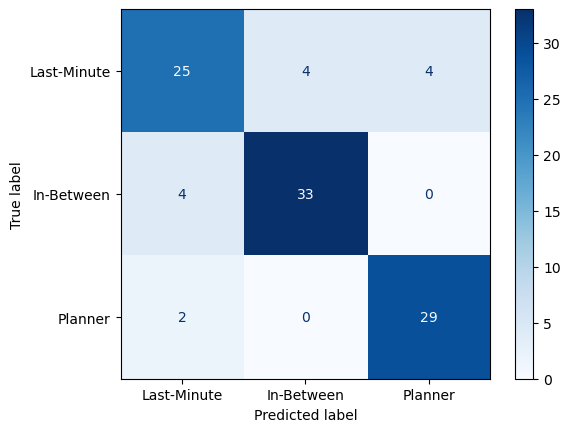

In [114]:
best_matrix = confusion_matricies[int(best_fold['fold'] - 1)]
disp = ConfusionMatrixDisplay(confusion_matrix=best_matrix, display_labels=list(DATA[clf_label].unique()))
disp.plot(cmap=plt.cm.Blues)

### Regression Analysis

/var/folders/tq/l2s3vhss5w35491l7pm655kw0000gp/T/ipykernel_5589/4097579899.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  best_reg = resid_plots[int(best_fold['fold'] - 1)]


Text(0, 0.5, 'Residual')

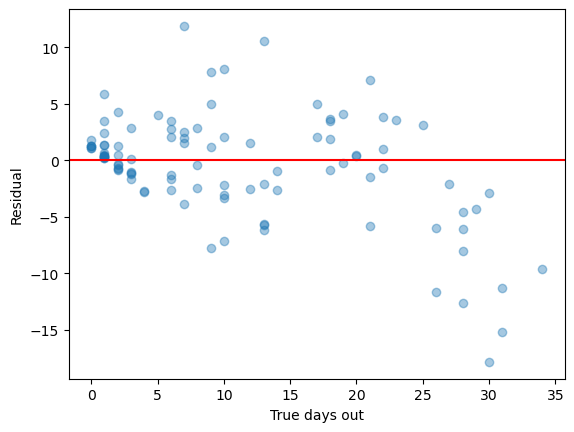

In [115]:
best_reg = resid_plots[int(best_fold['fold'] - 1)]
r_true, r_pred = best_reg[0], best_reg[1]
plt.scatter(r_true, r_pred - r_true, alpha=0.4)
plt.axhline(0, color='r')
plt.xlabel('True days out')
plt.ylabel('Residual')

Initial model reports sytematic bias that will try to account for by log-transforming into the dataset.